# 02 — Club Analysis

Objetivo: transformar os dados dos tacos da Smart Calc em uma tabela analítica para entender diferenças de potência, ângulo, spin e curva.

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

sys.path.append(str(src_path))

print(src_path)

c:\Users\felip\OneDrive\Documentos\Nova pasta\pangya-shot-physics\src


In [4]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt

from pangya_physics.club import CLUBS

In [5]:
# DataFrame

clubs_data = []

for club_name, club in CLUBS.items():
    clubs_data.append(
        {
            "club": club_name,
            "type": club.club_type.value,
            "rotation_spin": club.rotation_spin,
            "rotation_curve": club.rotation_curve,
            "power_factor": club.power_factor,
            "degree": club.degree,
            "power_base": club.power_base,
        }
    )

df_clubs = pd.DataFrame(clubs_data)

df_clubs

,club,type,rotation_spin,rotation_curve,power_factor,degree,power_base
0,1W,wood,0.55,1.61,236.0,10.0,230.0
1,2W,wood,0.50,1.41,204.0,13.0,210.0
2,3W,wood,0.45,1.26,176.0,16.0,190.0
3,2I,iron,0.45,1.07,161.0,20.0,180.0
4,3I,iron,0.45,0.95,149.0,24.0,170.0
5,4I,iron,0.45,0.83,139.0,28.0,160.0
6,5I,iron,0.45,0.73,131.0,32.0,150.0
7,6I,iron,0.41,0.67,124.0,36.0,140.0
8,7I,iron,0.36,0.61,118.0,40.0,130.0
9,8I,iron,0.30,0.57,114.0,44.0,120.0


In [6]:
# Estatísticas

df_clubs.describe()

,rotation_spin,rotation_curve,power_factor,degree,power_base
count,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.382308,0.857692,143.230769,32.230769,151.538462
std,0.121254,0.378267,41.523395,15.221442,44.129762
min,0.170000,0.420000,93.000000,10.000000,80.000000
25%,0.300000,0.570000,114.000000,20.000000,120.000000
50%,0.450000,0.730000,131.000000,32.000000,150.000000
75%,0.450000,1.070000,161.000000,44.000000,180.000000
max,0.550000,1.610000,236.000000,56.000000,230.000000


In [7]:
# Ordenar por potência

df_clubs.sort_values("power_factor", ascending=False)

,club,type,rotation_spin,rotation_curve,power_factor,degree,power_base
0,1W,wood,0.55,1.61,236.0,10.0,230.0
1,2W,wood,0.50,1.41,204.0,13.0,210.0
2,3W,wood,0.45,1.26,176.0,16.0,190.0
3,2I,iron,0.45,1.07,161.0,20.0,180.0
4,3I,iron,0.45,0.95,149.0,24.0,170.0
5,4I,iron,0.45,0.83,139.0,28.0,160.0
6,5I,iron,0.45,0.73,131.0,32.0,150.0
7,6I,iron,0.41,0.67,124.0,36.0,140.0
8,7I,iron,0.36,0.61,118.0,40.0,130.0
9,8I,iron,0.30,0.57,114.0,44.0,120.0


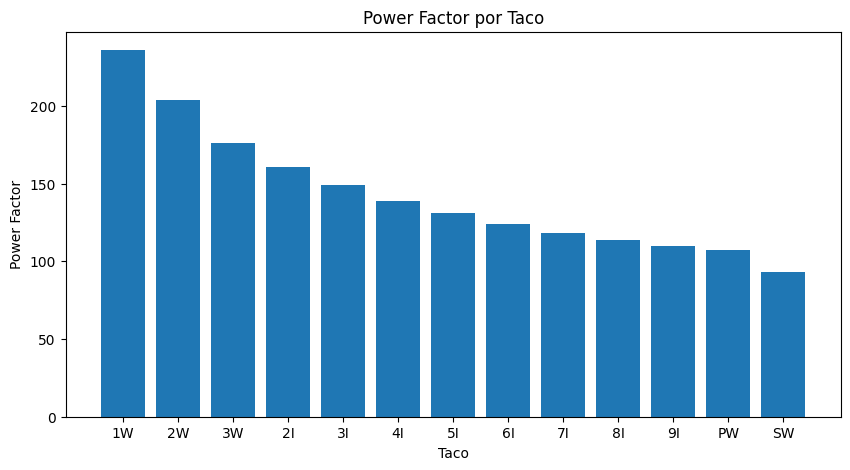

In [8]:
# Gráfico power factor

plt.figure(figsize=(10, 5))
plt.bar(df_clubs["club"], df_clubs["power_factor"])
plt.title("Power Factor por Taco")
plt.xlabel("Taco")
plt.ylabel("Power Factor")
plt.show()

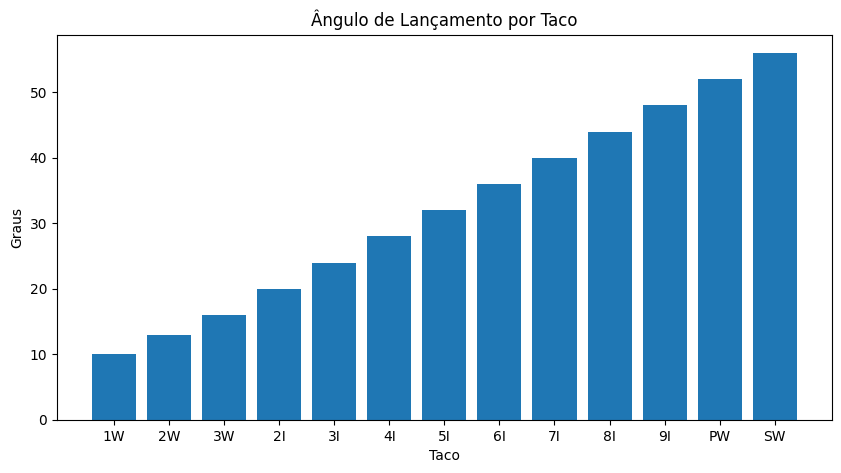

In [9]:
# Gráfico ângulo

plt.figure(figsize=(10, 5))
plt.bar(df_clubs["club"], df_clubs["degree"])
plt.title("Ângulo de Lançamento por Taco")
plt.xlabel("Taco")
plt.ylabel("Graus")
plt.show()

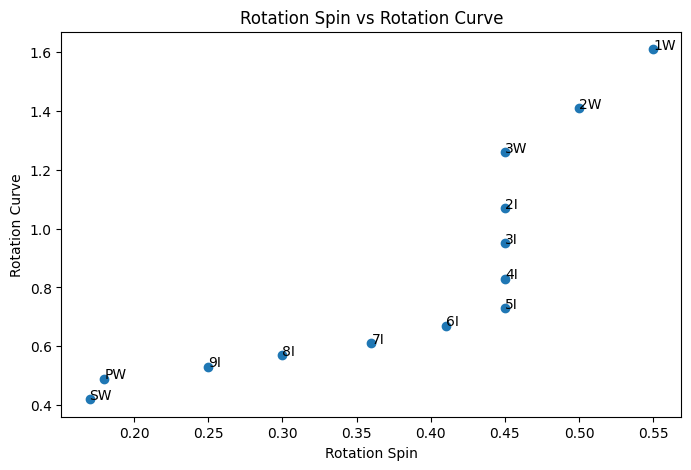

In [10]:
# Spin vs Curva

plt.figure(figsize=(8, 5))
plt.scatter(df_clubs["rotation_spin"], df_clubs["rotation_curve"])

for _, row in df_clubs.iterrows():
    plt.text(
        row["rotation_spin"],
        row["rotation_curve"],
        row["club"],
    )

plt.title("Rotation Spin vs Rotation Curve")
plt.xlabel("Rotation Spin")
plt.ylabel("Rotation Curve")
plt.show()

## Conclusões iniciais

- Woods têm maior power factor e menor ângulo de lançamento.
- Wedges têm menor power factor e maior ângulo.
- O 1W combina alta potência com alto fator de curva.
- O ângulo do taco cresce conforme a potência base diminui.
- Esses dados serão usados depois para análise de sensibilidade e simulação de trajetória.